Lifecycle in a data science project :
1. data analysis
2. feature engineering
3. feature selection
4. model building
5. model deployment


column = feature


In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [137]:
#aim : to understand more about the data

##display all the coloumn sof the dataset

pd.pandas.set_option('display.max_columns' , None )

In [138]:
df = pd.read_csv('house.csv')

##print the shape of dataset with rowns and columns
print(df.shape)

(1460, 81)


In [139]:
df.head() #prints the top 5 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


DATA ANALYSIS

in data analysis , we analyse to find out the below stuff :
1. missing values
2. all the numerical variables
3. distribution of the numerical variables
4. categorical variables
5. cardibality of categorical variables
6. outliers
7. relationship between independent and dependent feature (saleprice)

In [140]:
#checking %age of nan values in each feature .
## 1. make the list of feautures having nan values
features_with_na = [features for features in df.columns if df[features].isnull().sum()>1]
#a list of all column names where the number of missing values is greater than 1."
##print the feature name and the %age of missing values
for feature in features_with_na:
    print(feature , np.round(df[feature].isnull().mean() , 4) , '% missing values ')
    #For each column that has missing values, print its name and what percentage of its values are missing."

##mean()This is the clever part. Since True = 1 and False = 0, taking the mean gives you the proportion of missing values.For example, if 50 out of 200 rows are missing → mean = 50/200 = 0.25 → meaning 25% are missing.


LotFrontage 0.1774 % missing values 
Alley 0.9377 % missing values 
MasVnrType 0.5973 % missing values 
MasVnrArea 0.0055 % missing values 
BsmtQual 0.0253 % missing values 
BsmtCond 0.0253 % missing values 
BsmtExposure 0.026 % missing values 
BsmtFinType1 0.0253 % missing values 
BsmtFinType2 0.026 % missing values 
FireplaceQu 0.4726 % missing values 
GarageType 0.0555 % missing values 
GarageYrBlt 0.0555 % missing values 
GarageFinish 0.0555 % missing values 
GarageQual 0.0555 % missing values 
GarageCond 0.0555 % missing values 
PoolQC 0.9952 % missing values 
Fence 0.8075 % missing values 
MiscFeature 0.963 % missing values 


since there are many missing values , we need to find the relationship between missing values and sales price

In [141]:
#plotting the comparison abr graph

for feature in features_with_na:
    data = df.copy()

    #lets make a variable that indicates 1 if the observation was missing
    data[feature] = np.where(data[feature].isnull() , 1,0)
    #above code is NumPy's version of an if-else statement.
    ##written as -- np.where(condition, value_if_true, value_if_false)

<function matplotlib.pyplot.show(close=None, block=None)>

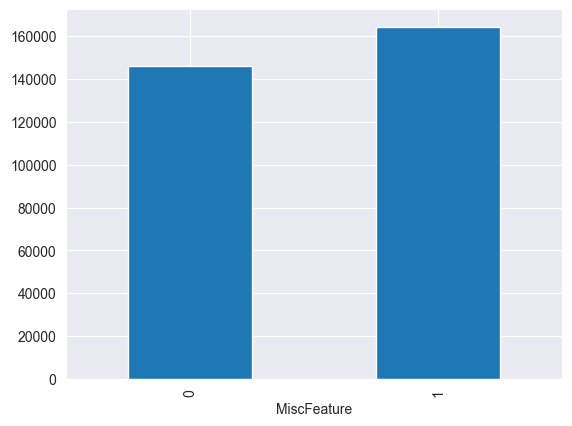

In [142]:

#lets calculate the mean saleprice where the info is missing

data.groupby(feature)['SalePrice'].median().plot.bar()
plt.show

Why is this useful?
If the two bars are very different heights, it means whether a value was missing or not actually influences the Sale Price — so that missing-ness is meaningful and worth keeping as a feature in your model!
If the bars are roughly the same height, the missing-ness doesn't tell you much.
This is a smart and common technique in Exploratory Data Analysis (EDA)!

In [143]:
#from above columns , the column id is not required so we can drop it

In [144]:
print("Id of houses {} " .format(len(df.Id))) #count of ID.

Id of houses 1460 


Numerical variables

In [162]:
#list of numerical variables
numerical_features = [feature for feature in df.columns if df[feature].dtype!= 'str' and df[feature].dtype != str]

print('Number of numerical variables :' , len(numerical_features))

#visualize the numerical variables
df[numerical_features].head()

Number of numerical variables : 38


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000


In [164]:
print(len(numerical_features))
print(numerical_features)


38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


Temporal variables (Eg :datetime variables )
So the key idea is:

Instead of using the raw year, calculate the difference between years — because age/elapsed time is what actually influences the Sale Price, not the year itself.

A house built in 1950 and sold in 2010 is 60 years old — that's what matters to the model!

In [165]:
#list of variable that contain year info
year_feature = [feature for feature in numerical_features if 'Yr' in feature or 'Year' in feature]

In [166]:
year_feature


['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']

In [167]:
#exploring the content of these year variables
for feature in year_feature:
    print(feature , df[feature].unique())
#.unique -  Returns all the distinct/different values in that column — removes duplicates.
#So instead of seeing the same year repeated thousands of times, you just see each year once.

YearBuilt [2003 1976 2001 1915 2000 1993 2004 1973 1931 1939 1965 2005 1962 2006
 1960 1929 1970 1967 1958 1930 2002 1968 2007 1951 1957 1927 1920 1966
 1959 1994 1954 1953 1955 1983 1975 1997 1934 1963 1981 1964 1999 1972
 1921 1945 1982 1998 1956 1948 1910 1995 1991 2009 1950 1961 1977 1985
 1979 1885 1919 1990 1969 1935 1988 1971 1952 1936 1923 1924 1984 1926
 1940 1941 1987 1986 2008 1908 1892 1916 1932 1918 1912 1947 1925 1900
 1980 1989 1992 1949 1880 1928 1978 1922 1996 2010 1946 1913 1937 1942
 1938 1974 1893 1914 1906 1890 1898 1904 1882 1875 1911 1917 1872 1905]
YearRemodAdd [2003 1976 2002 1970 2000 1995 2005 1973 1950 1965 2006 1962 2007 1960
 2001 1967 2004 2008 1997 1959 1990 1955 1983 1980 1966 1963 1987 1964
 1972 1996 1998 1989 1953 1956 1968 1981 1992 2009 1982 1961 1993 1999
 1985 1979 1977 1969 1958 1991 1971 1952 1975 2010 1984 1986 1994 1988
 1954 1957 1951 1978 1974]
GarageYrBlt [2003. 1976. 2001. 1998. 2000. 1993. 2004. 1973. 1931. 1939. 1965. 2005.
 1962. 2006.

In [149]:
#analyzing the temporal date time variables
##checking whether there is a relation bw year the house was sold nd sale price

<function matplotlib.pyplot.show(close=None, block=None)>

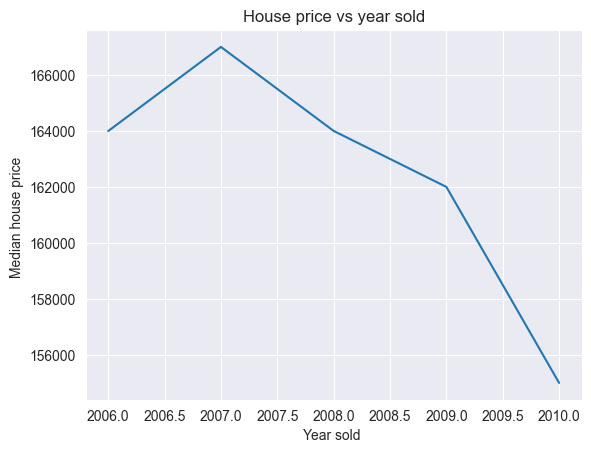

In [168]:
df.groupby('YrSold')['SalePrice'].median().plot()
plt.xlabel('Year sold ')
plt.ylabel('Median house price ')
plt.title("House price vs year sold")
plt.show
#dfgroupby('YrSold')Groups all rows by the year the house was sold.
#so all houses sold in 2006 go in one group, 2007 in another, and so on.

In [151]:
year_feature


['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']

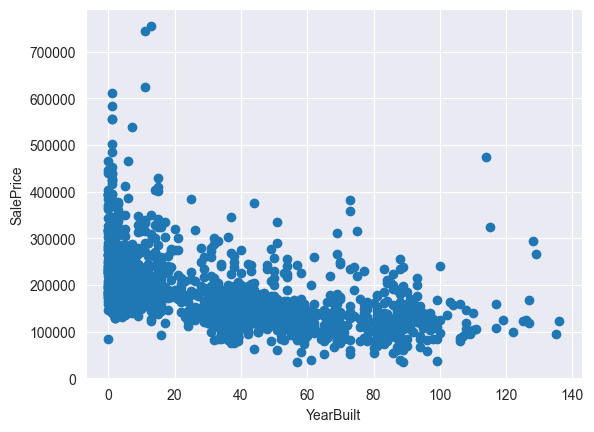

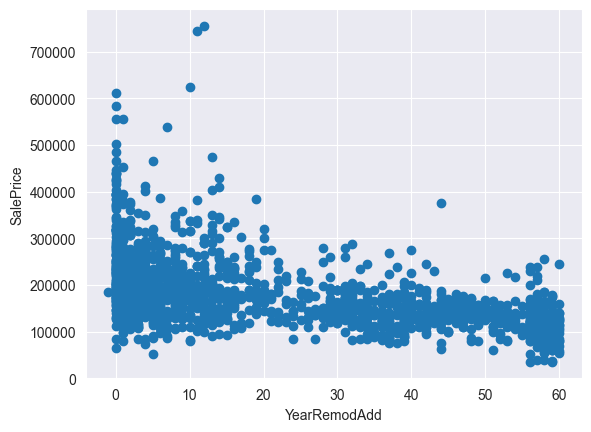

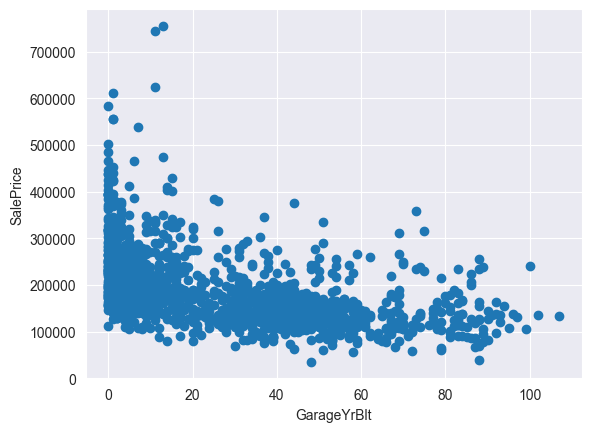

In [169]:
#comparing the difference between all years features with Sale price.
##"For each year column, convert it to age by subtracting from YrSold, then plot it against SalePrice to see the relationship."
for feature in year_feature:
    if feature != 'YrSold':
        data = df.copy()

        ##capturing the difference bw year variable and year the house was built

        data[feature] = data['YrSold'] - data[feature]

        plt.scatter(data[feature], data['SalePrice'])
        plt.xlabel(feature)
        plt.ylabel('SalePrice')
        plt.show()

In [170]:
#numerical value srae of 2 types
## 1. continuous variable and discrete variables

discrete_feature = [feature for feature in numerical_features if len(df[feature].unique())<25 and feature not in year_feature + ['Id']]
print("Discrete Variables Count: {} ".format(len(discrete_feature)))

Discrete Variables Count: 17 


In [171]:
discrete_feature

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold']

In [172]:
print(len(discrete_feature))

17


In [173]:
df[discrete_feature].head()


,MSSubClass,OverallQual,OverallCond,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,3SsnPorch,PoolArea,MiscVal,MoSold
0,60,7,5,0,1,0,2,1,3,1,8,0,2,0,0,0,2
1,20,6,8,0,0,1,2,0,3,1,6,1,2,0,0,0,5
2,60,7,5,0,1,0,2,1,3,1,6,1,2,0,0,0,9
3,70,7,5,0,1,0,1,0,3,1,7,1,3,0,0,0,2
4,60,8,5,0,1,0,2,1,4,1,9,1,3,0,0,0,12


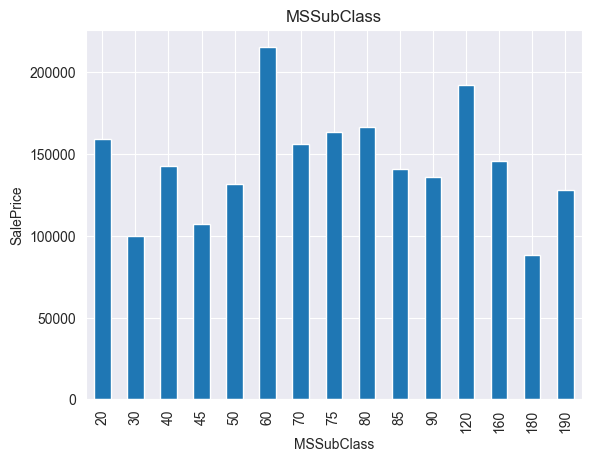

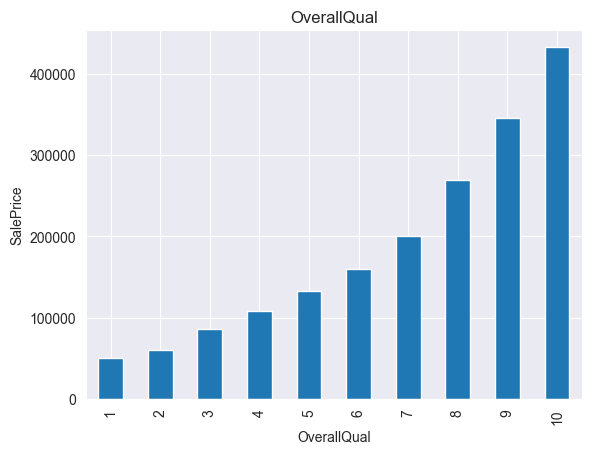

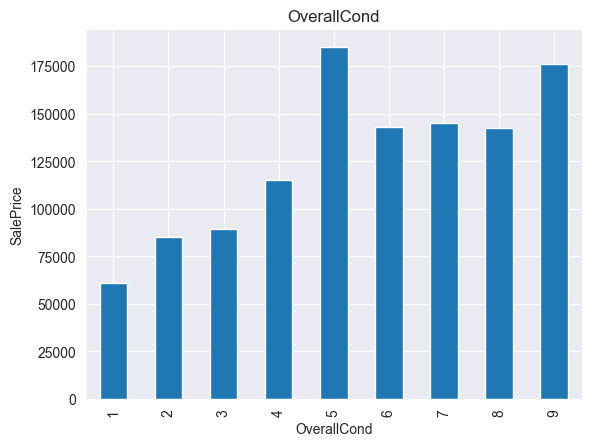

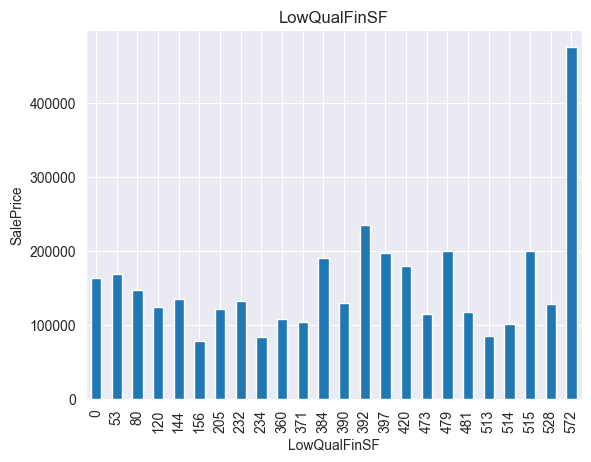

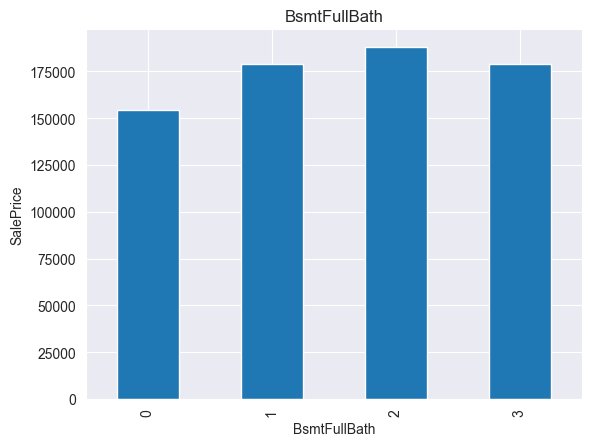

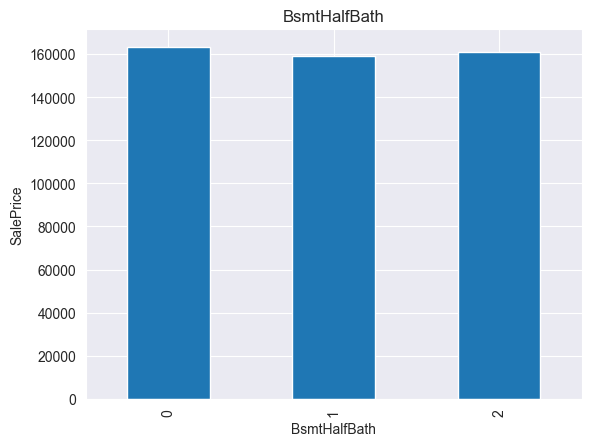

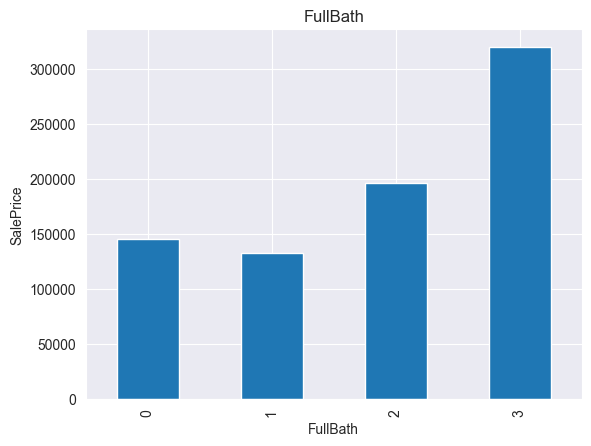

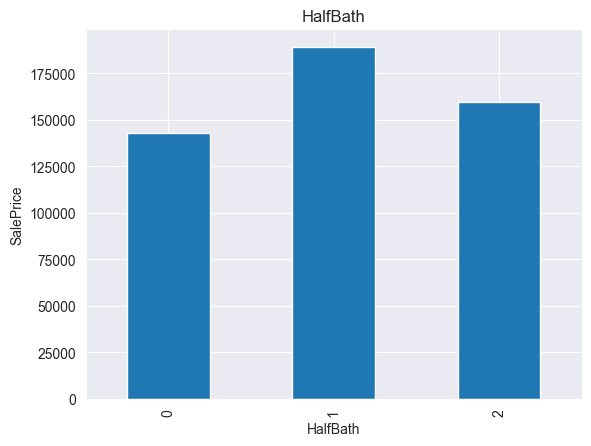

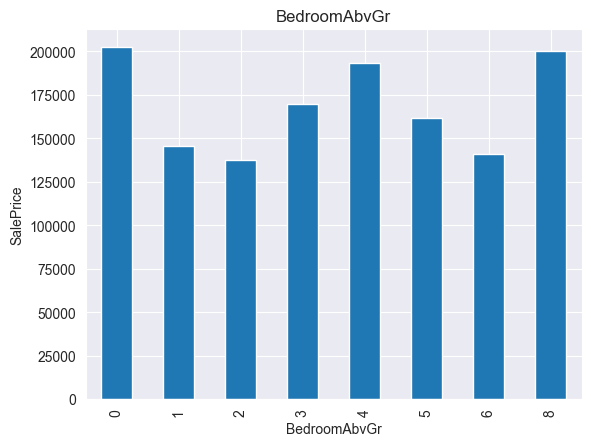

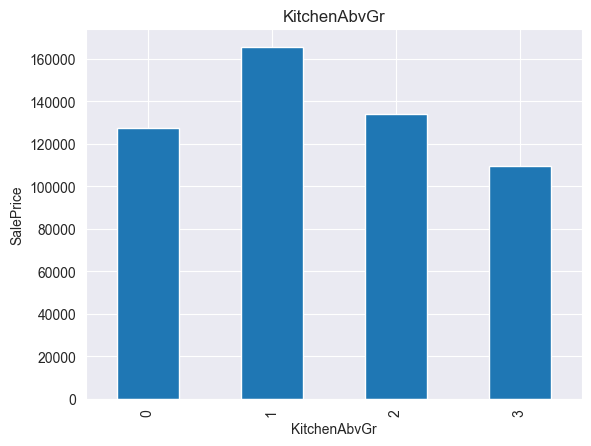

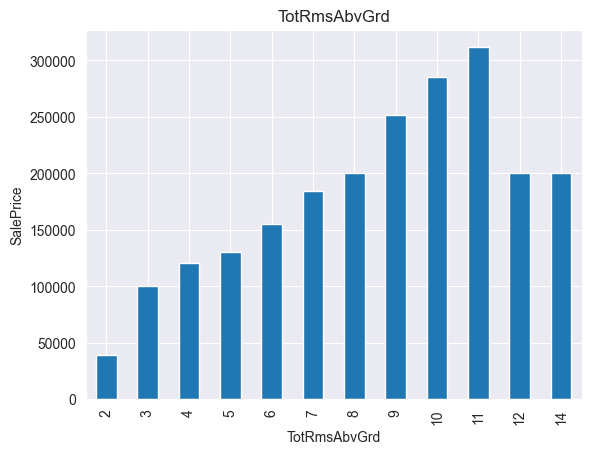

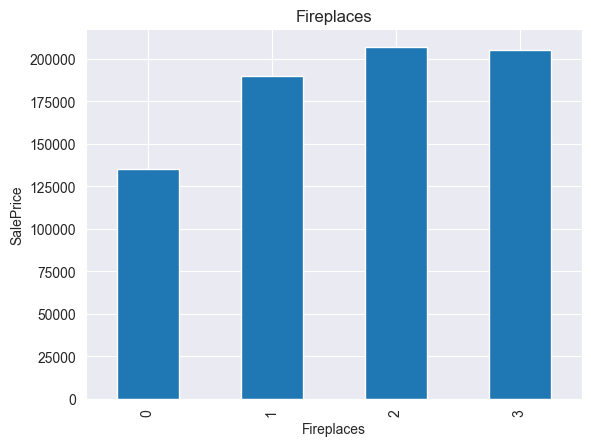

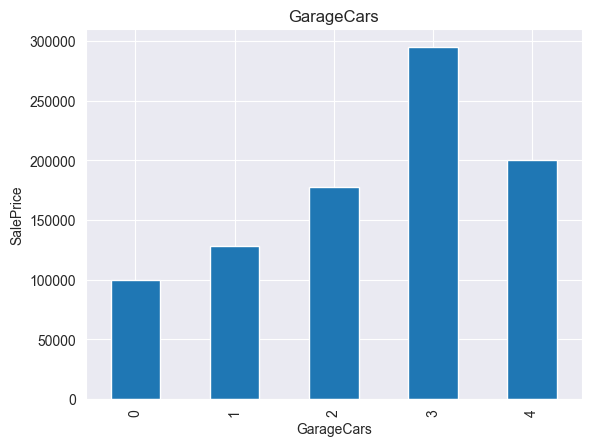

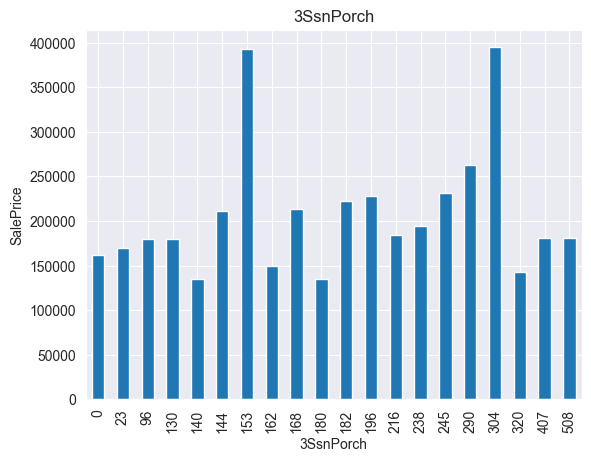

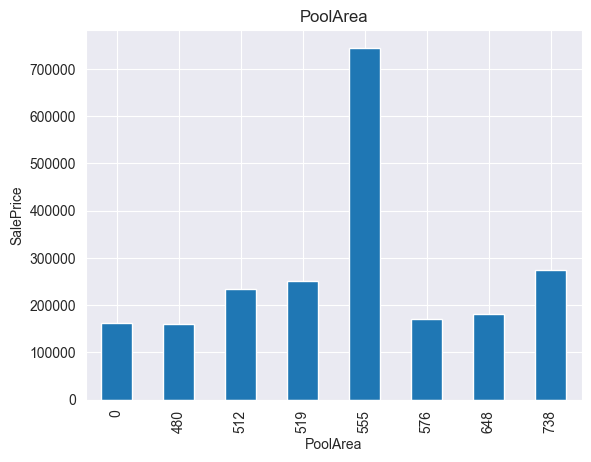

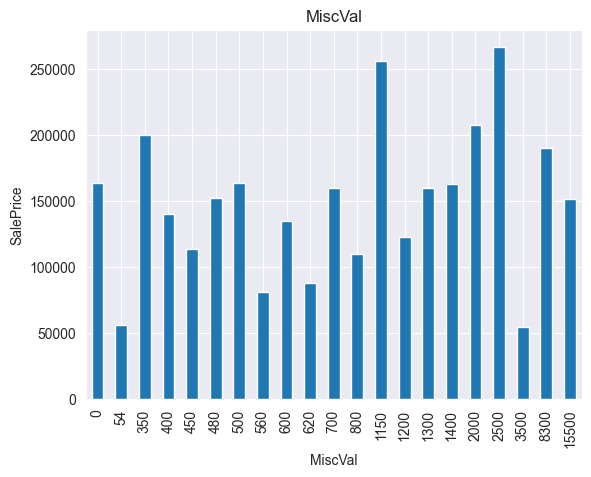

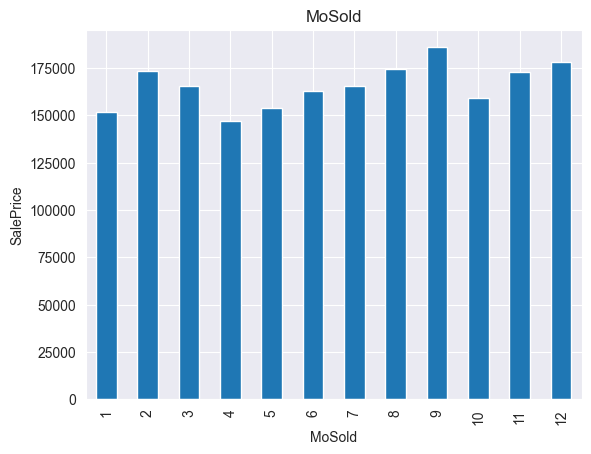

In [174]:
#finding the relationship between discrete feature and SalePrice

for feature in discrete_feature :
    data = df.copy()
    data.groupby(feature)['SalePrice'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.title(feature)
    plt.show()

In [175]:
#continuous variable

cont_feature = [feature for feature in numerical_features if feature not in discrete_feature + year_feature +['Id'] ]
print("Continuous feature count is {}" .format(len(cont_feature)))

Continuous feature count is 16


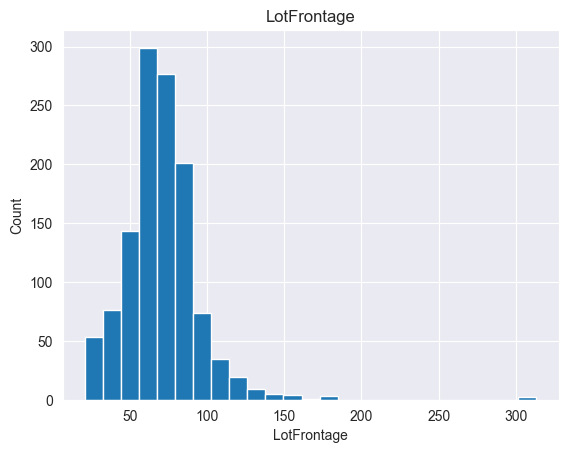

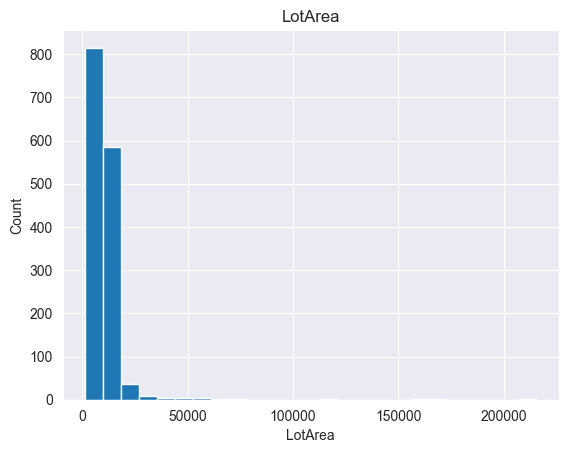

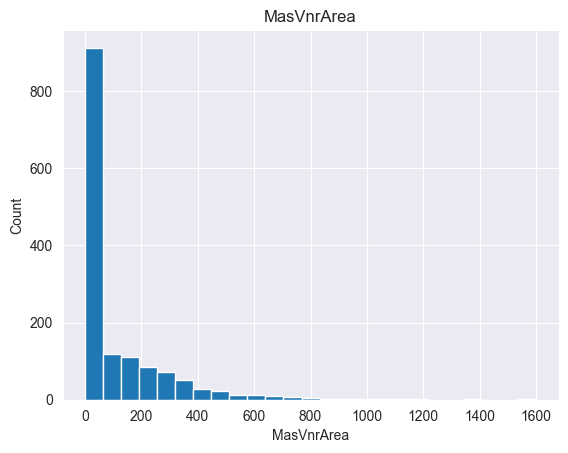

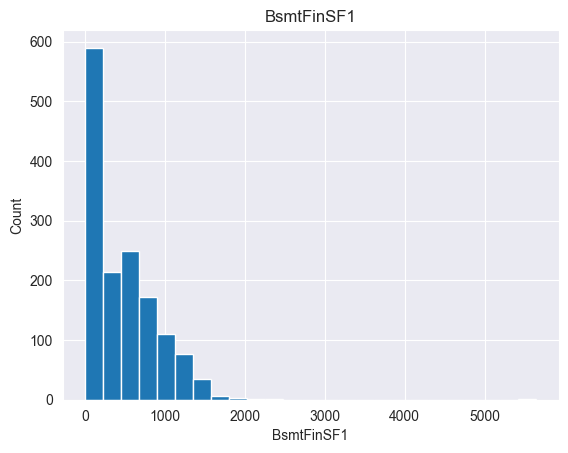

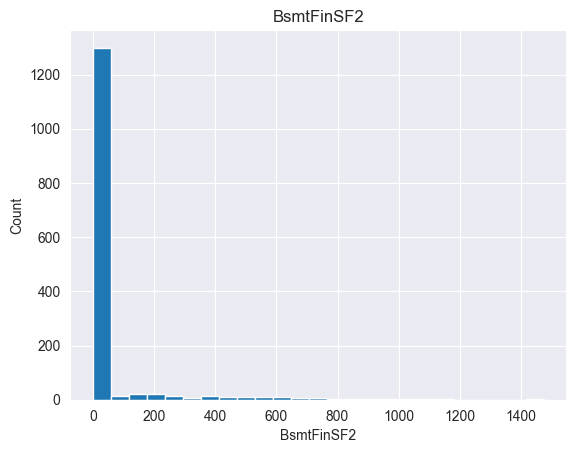

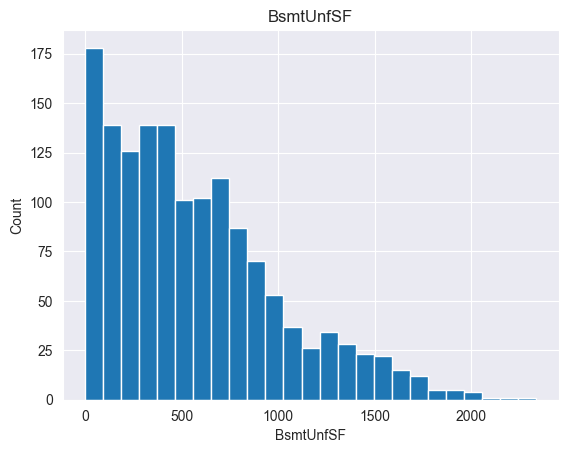

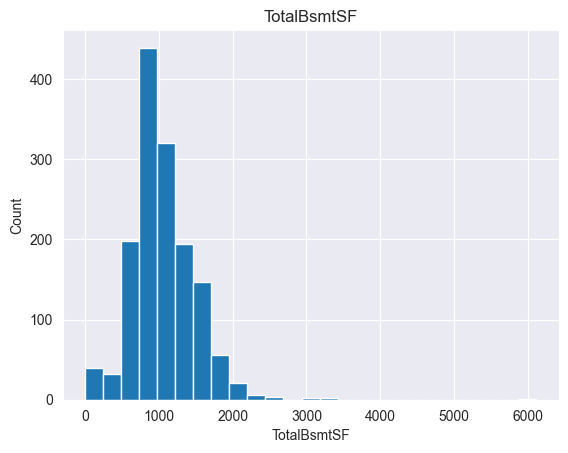

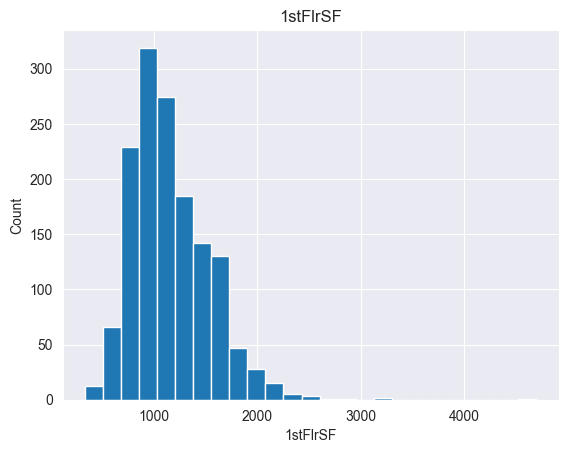

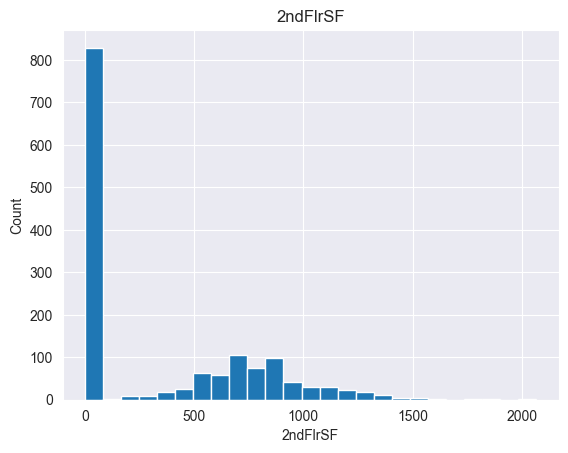

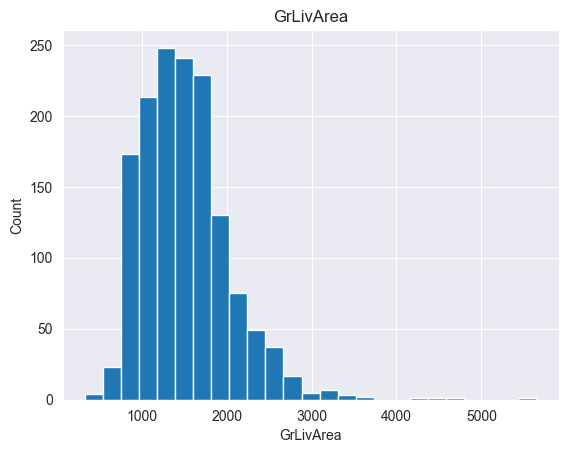

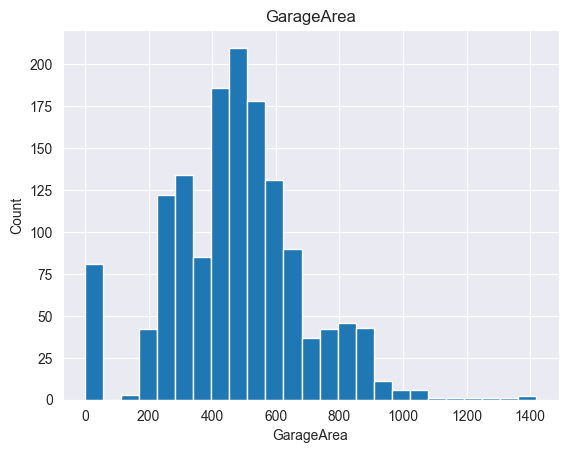

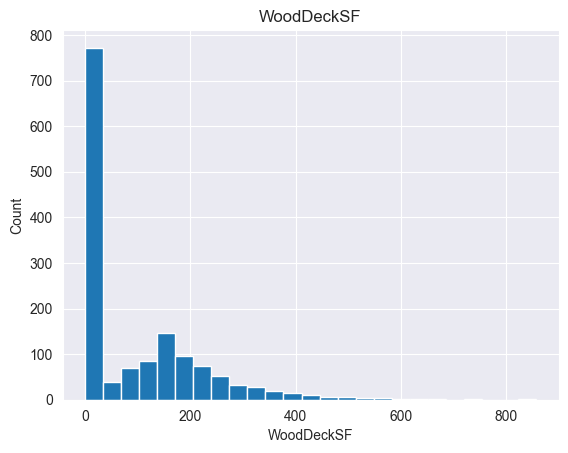

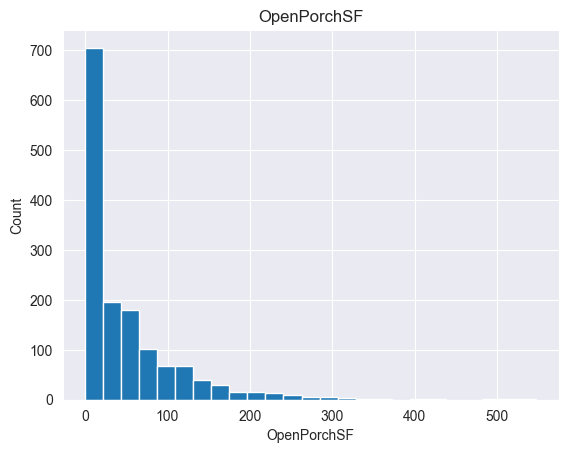

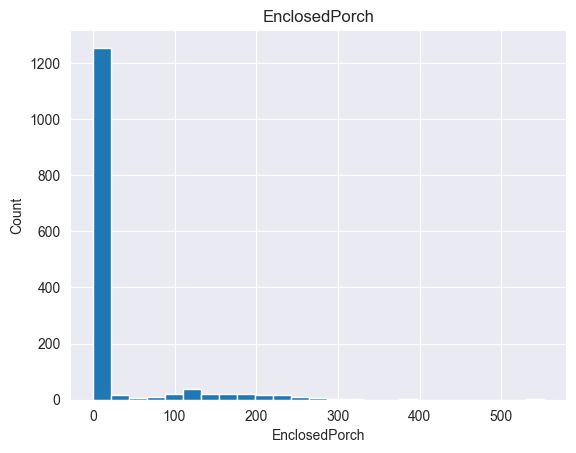

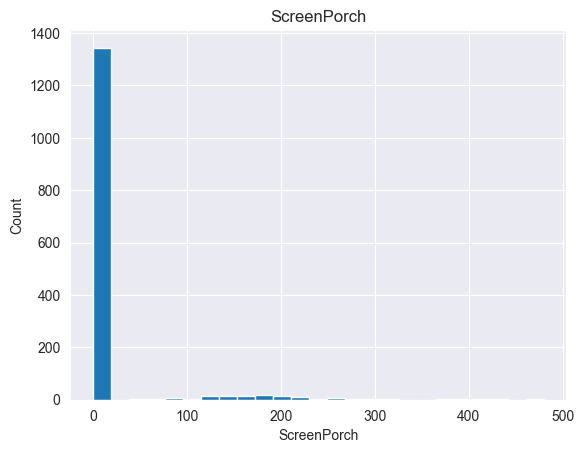

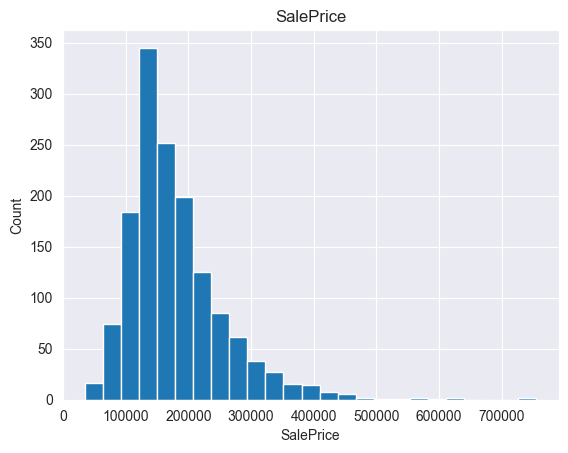

In [176]:
#analysing the continuous values by creating histograms to understandd  the distribution
##Few unique values (discrete)groupby → bar chartMany unique values (continuous)scatter plot directly
for feature in cont_feature:
    data = df.copy()
    data[feature].hist(bins = 25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

EDA Part 2

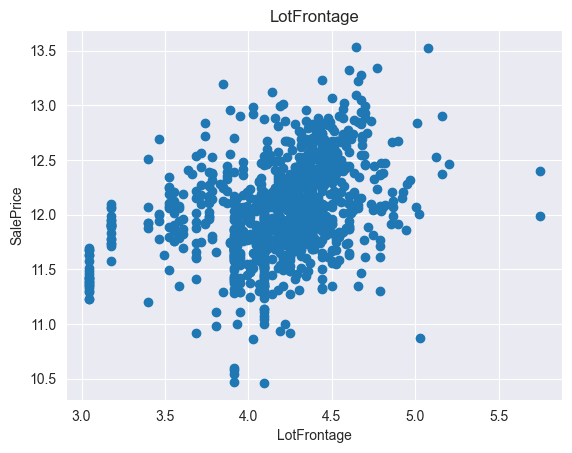

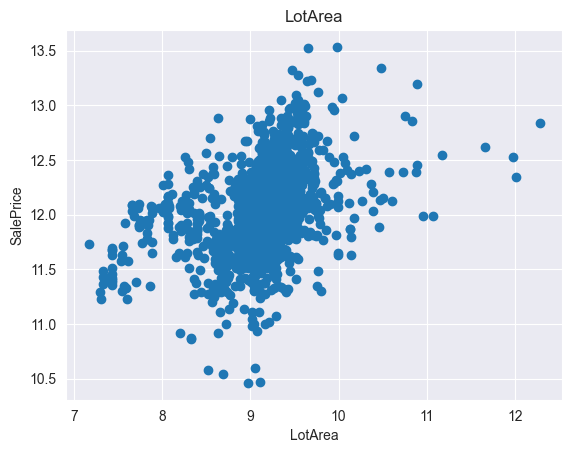

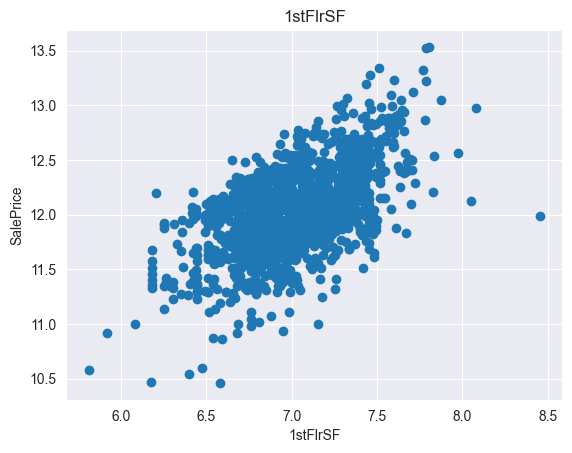

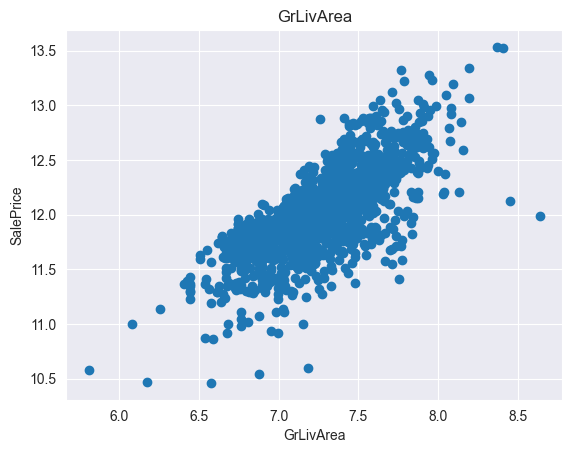

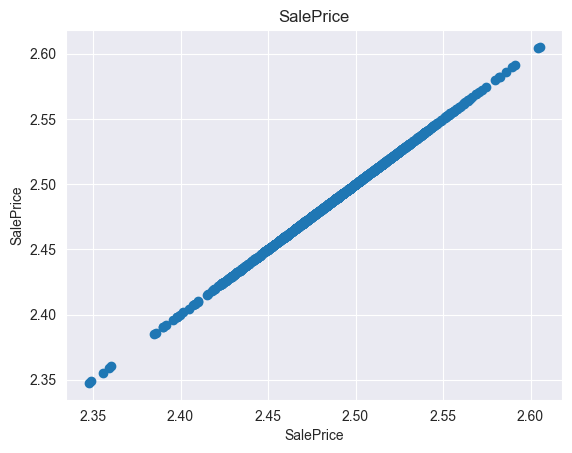

In [177]:
#using logarithmic transformation
for feature in cont_feature :
    data = df.copy()
    if 0 in data[feature].unique():
        pass
    else :
        data[feature] = np.log(data[feature])
        data['SalePrice'] = np.log(data['SalePrice'])
        plt.scatter(data[feature] , data['SalePrice'])
        plt.xlabel(feature)
        plt.ylabel('SalePrice')
        plt.title(feature)
        plt.show()


In [134]:
print(df.dtypes)


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


In [161]:
for feature in df.columns:
    print(feature , df[feature].dtype)

Id int64
MSSubClass int64
MSZoning str
LotFrontage float64
LotArea int64
Street str
Alley str
LotShape str
LandContour str
Utilities str
LotConfig str
LandSlope str
Neighborhood str
Condition1 str
Condition2 str
BldgType str
HouseStyle str
OverallQual int64
OverallCond int64
YearBuilt int64
YearRemodAdd int64
RoofStyle str
RoofMatl str
Exterior1st str
Exterior2nd str
MasVnrType str
MasVnrArea float64
ExterQual str
ExterCond str
Foundation str
BsmtQual str
BsmtCond str
BsmtExposure str
BsmtFinType1 str
BsmtFinSF1 int64
BsmtFinType2 str
BsmtFinSF2 int64
BsmtUnfSF int64
TotalBsmtSF int64
Heating str
HeatingQC str
CentralAir str
Electrical str
1stFlrSF int64
2ndFlrSF int64
LowQualFinSF int64
GrLivArea int64
BsmtFullBath int64
BsmtHalfBath int64
FullBath int64
HalfBath int64
BedroomAbvGr int64
KitchenAbvGr int64
KitchenQual str
TotRmsAbvGrd int64
Functional str
Fireplaces int64
FireplaceQu str
GarageType str
GarageYrBlt float64
GarageFinish str
GarageCars int64
GarageArea int64
GarageQual s

Outliers

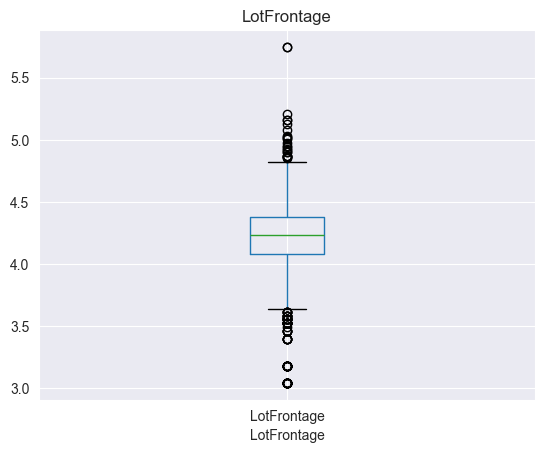

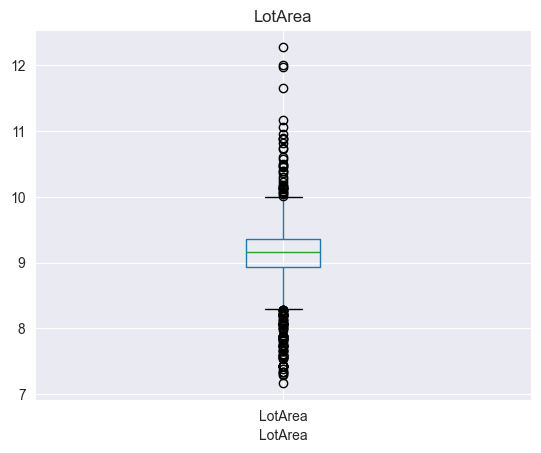

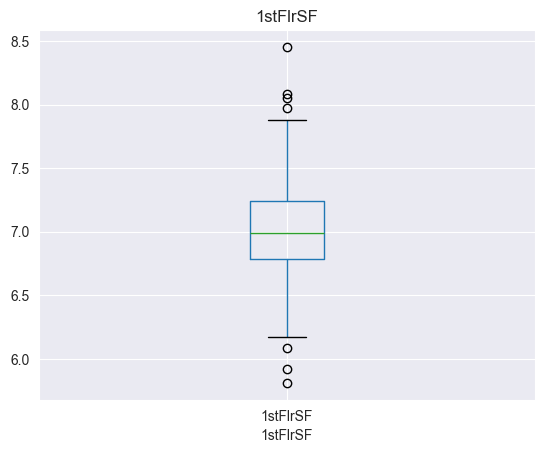

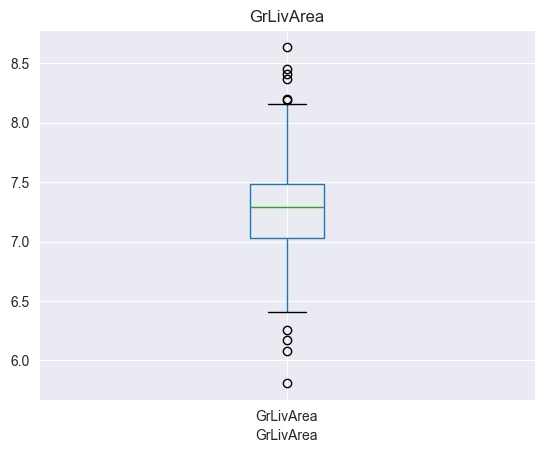

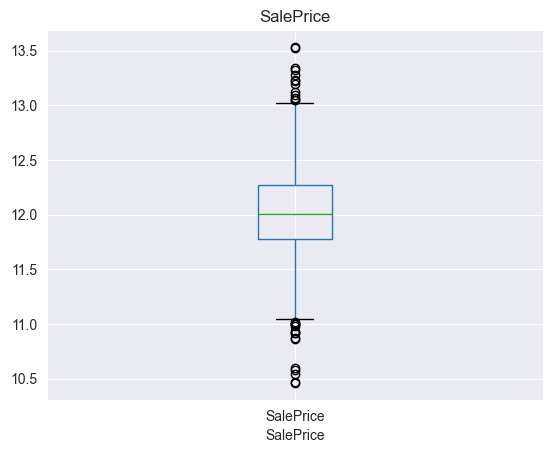

In [178]:
for feature in cont_feature:
    data = df.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature] = np.log(data[feature])
        data.boxplot(column = feature)
        plt.xlabel(feature)
        plt.title(feature)
        plt.show()


Categorical variables

In [188]:
categorical_feature = [feature for feature in df.columns if data[feature].dtype not in [ 'int64' , 'float64']]
print(len(categorical_feature))

43


In [189]:
print(categorical_feature)


['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [190]:
df[categorical_feature].head()


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [197]:
for  feature in categorical_feature:
    print("The feature is {} and the number of categories are {}." .format(feature ,len(df[feature].unique())))

The feature is MSZoning and the number of categories are 5.
The feature is Street and the number of categories are 2.
The feature is Alley and the number of categories are 3.
The feature is LotShape and the number of categories are 4.
The feature is LandContour and the number of categories are 4.
The feature is Utilities and the number of categories are 2.
The feature is LotConfig and the number of categories are 5.
The feature is LandSlope and the number of categories are 3.
The feature is Neighborhood and the number of categories are 25.
The feature is Condition1 and the number of categories are 9.
The feature is Condition2 and the number of categories are 8.
The feature is BldgType and the number of categories are 5.
The feature is HouseStyle and the number of categories are 8.
The feature is RoofStyle and the number of categories are 6.
The feature is RoofMatl and the number of categories are 8.
The feature is Exterior1st and the number of categories are 15.
The feature is Exterior

finding the relationship bw categprical variable and dependent feature

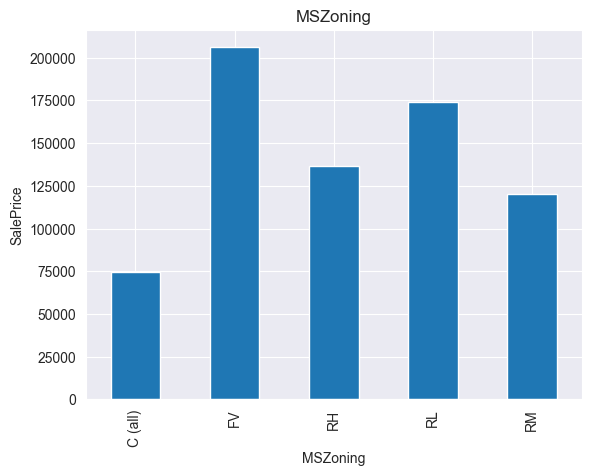

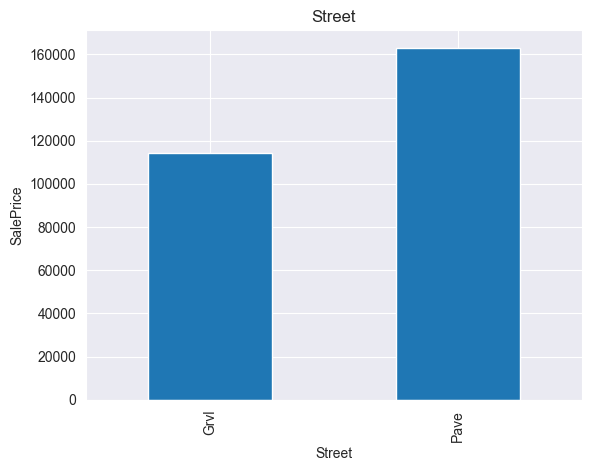

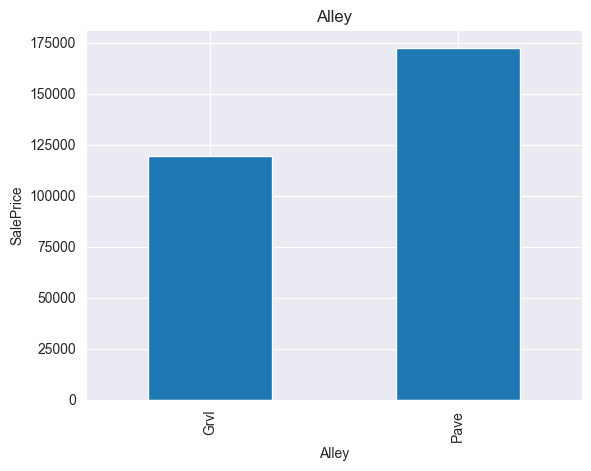

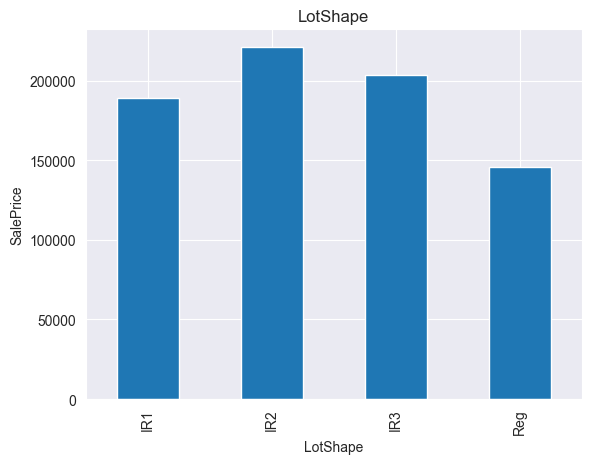

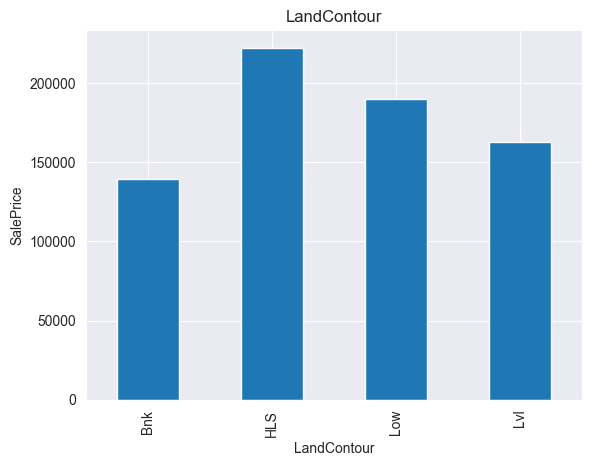

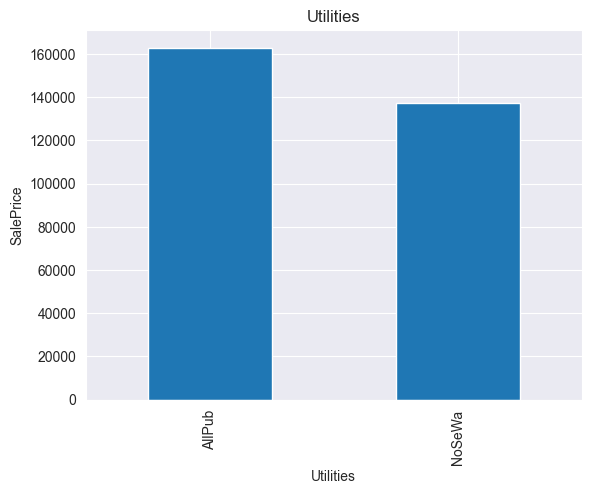

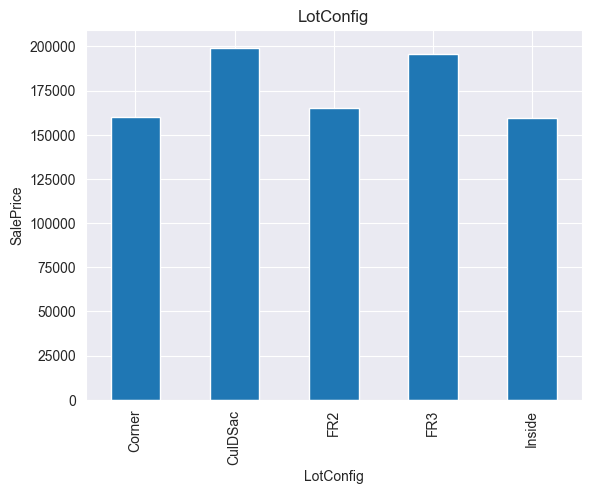

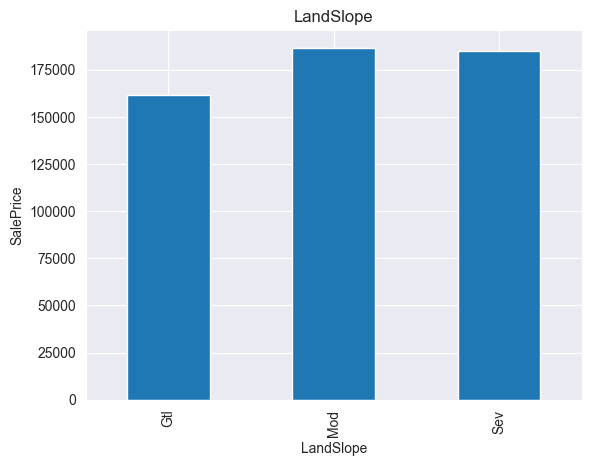

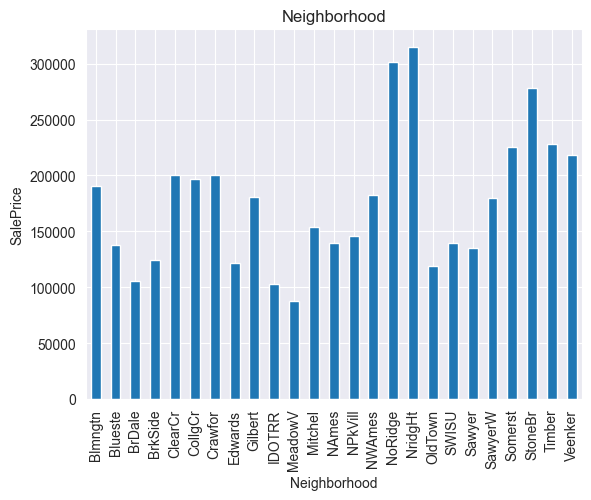

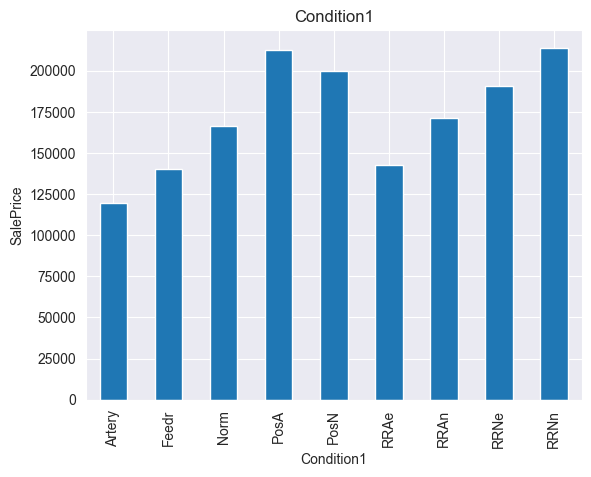

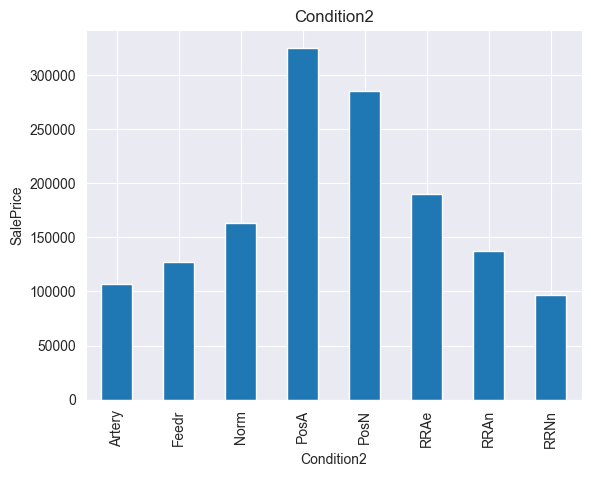

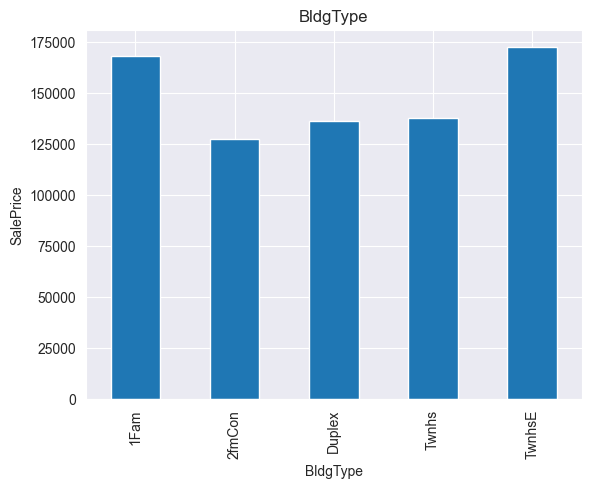

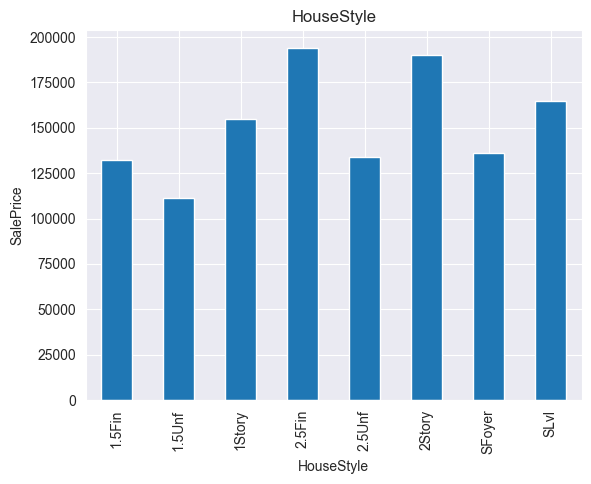

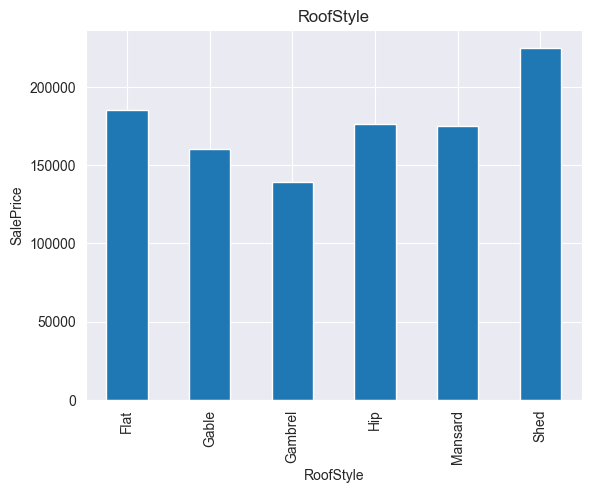

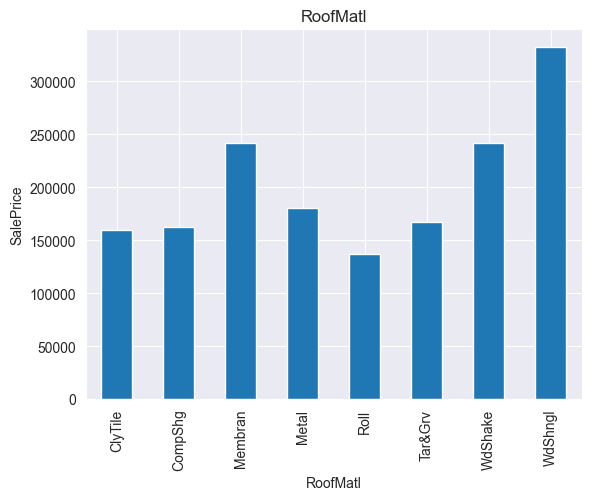

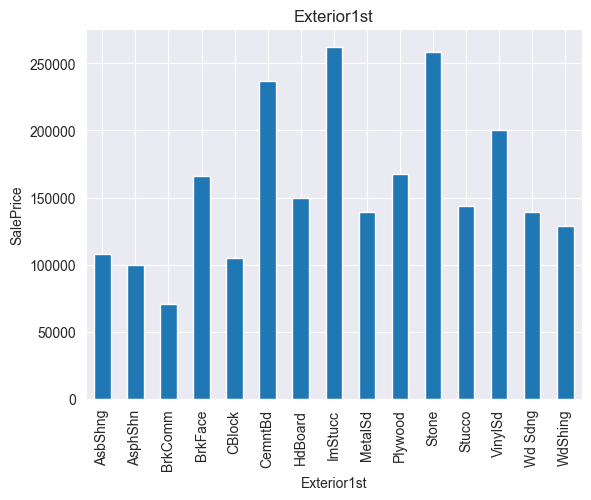

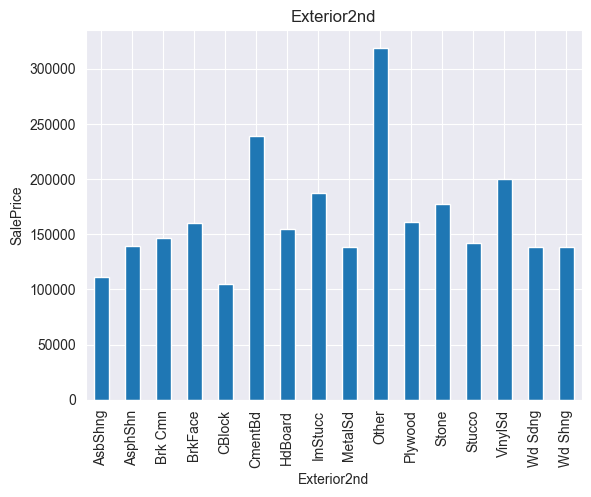

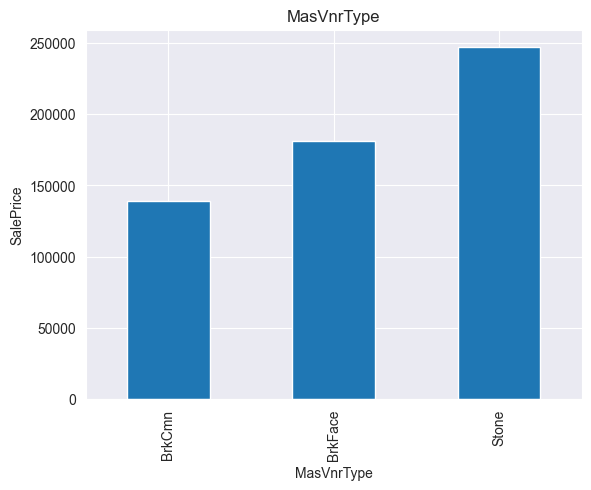

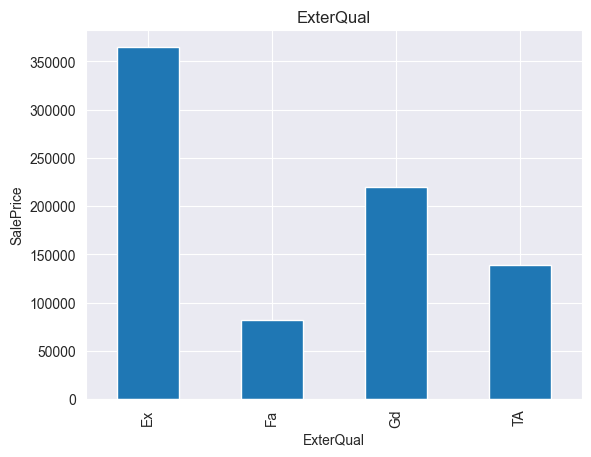

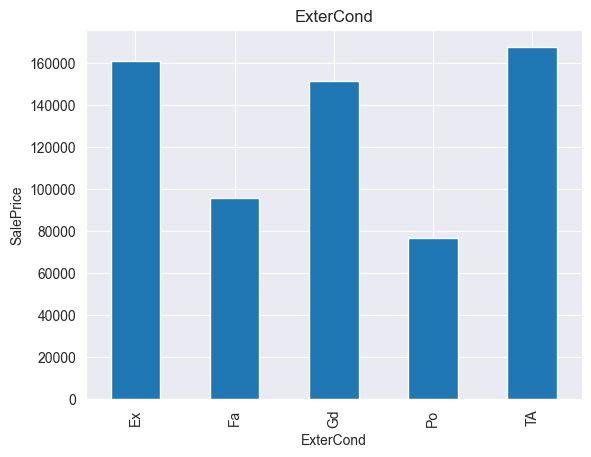

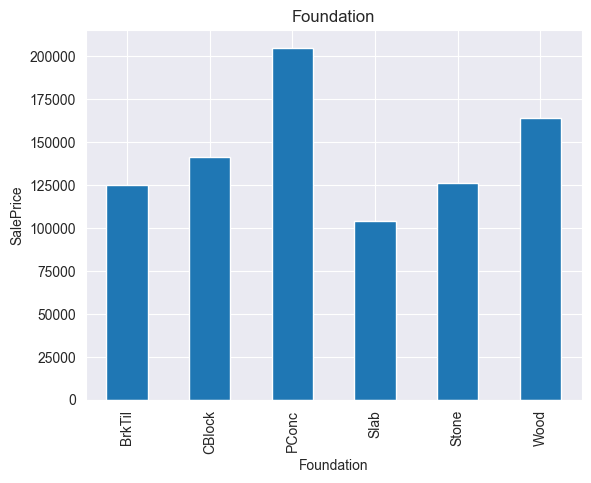

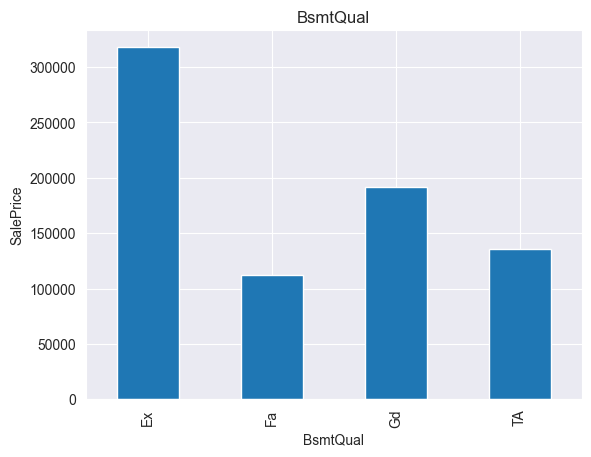

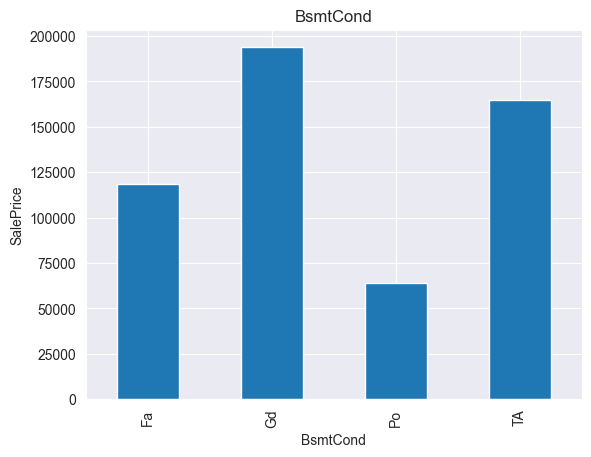

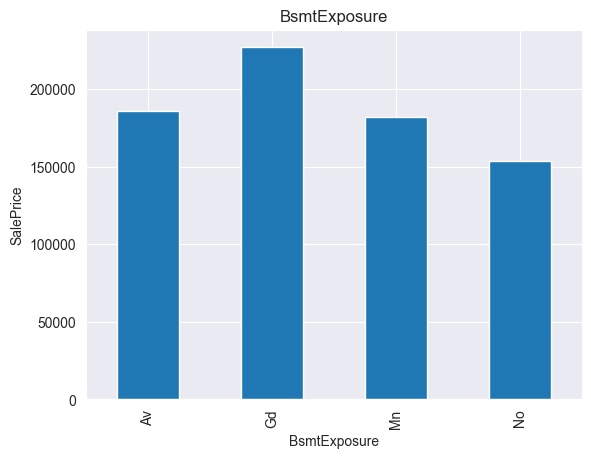

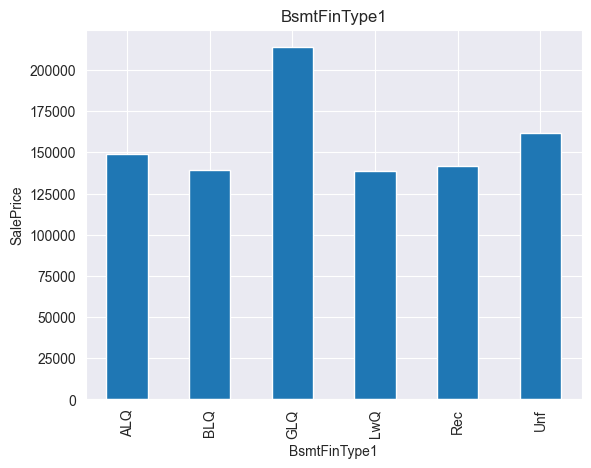

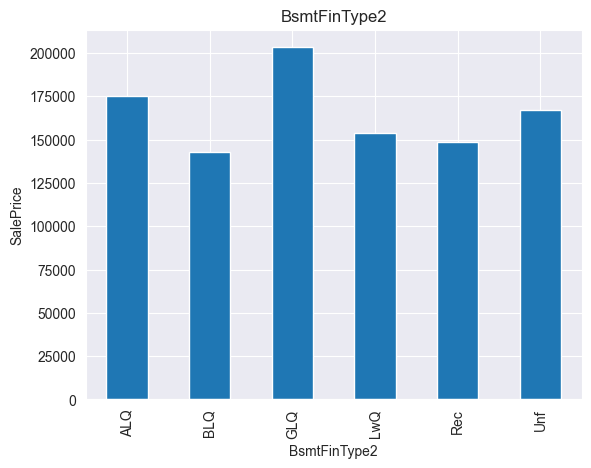

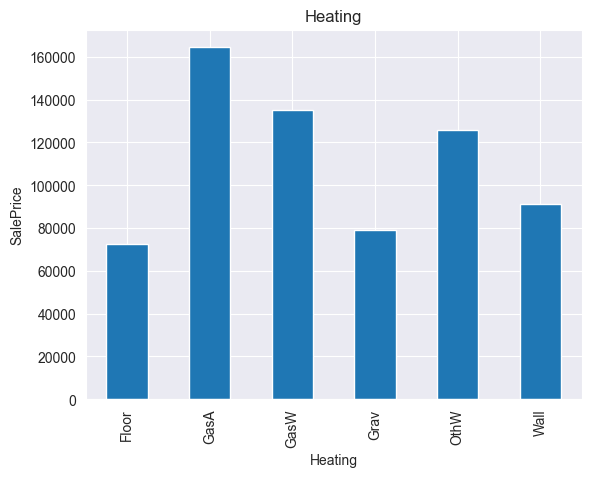

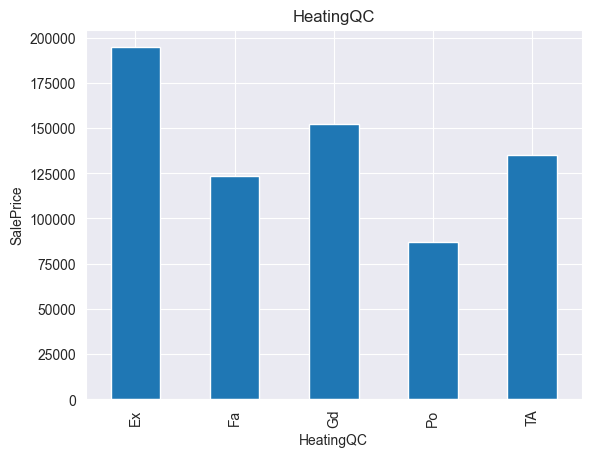

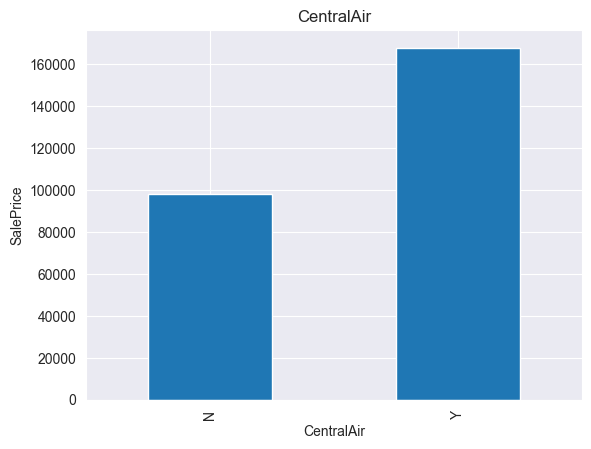

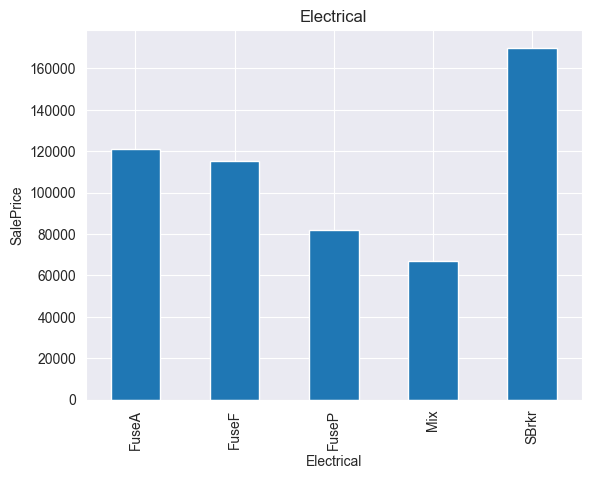

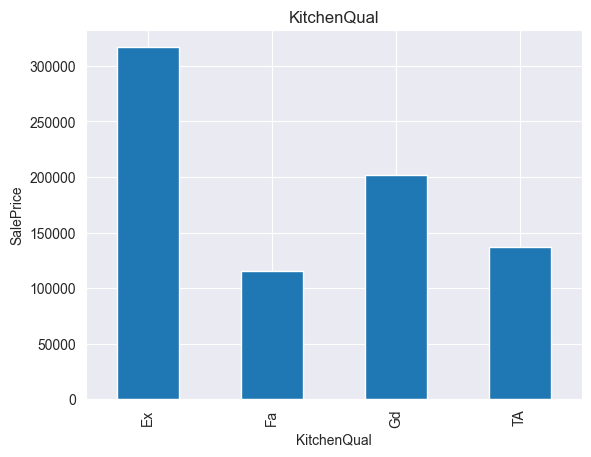

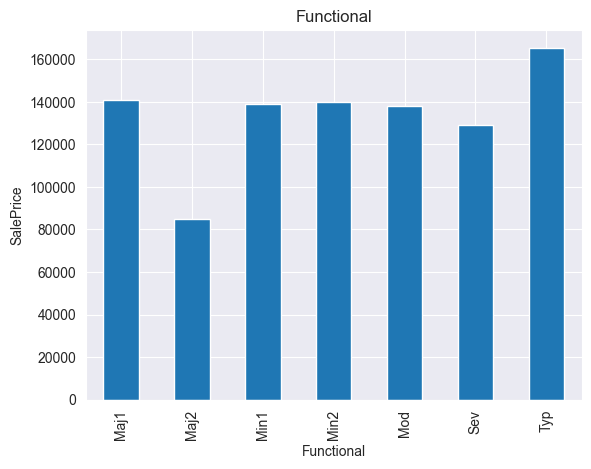

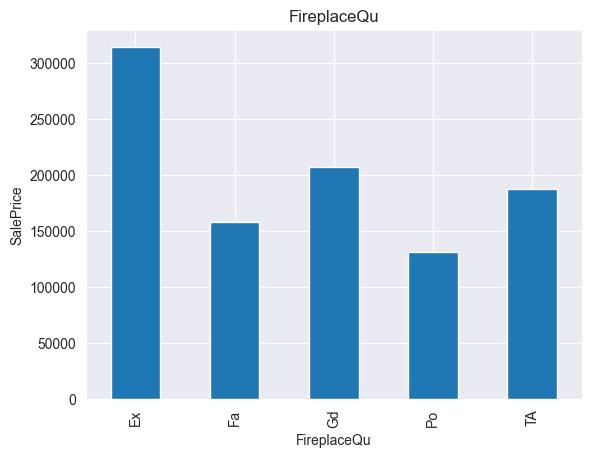

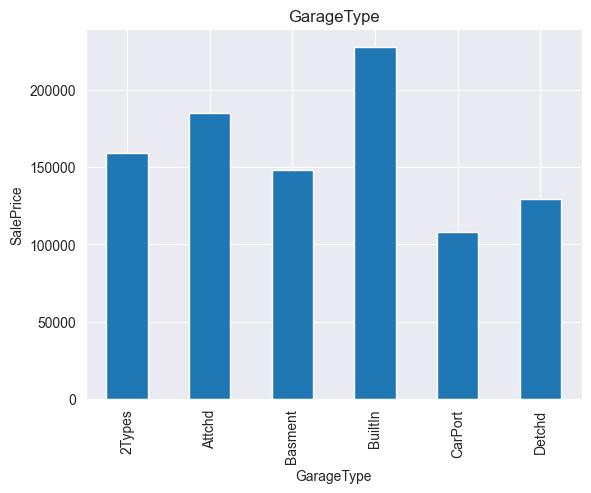

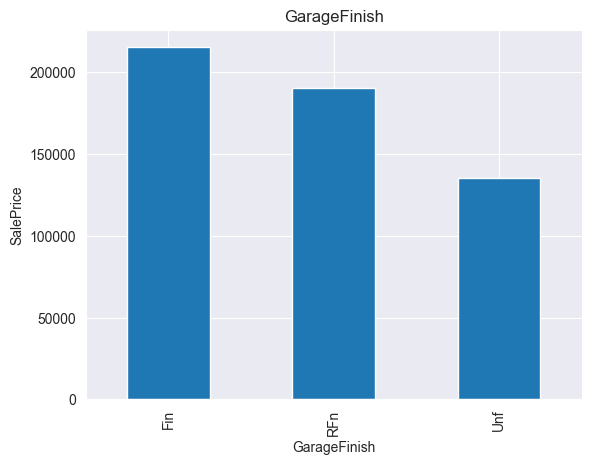

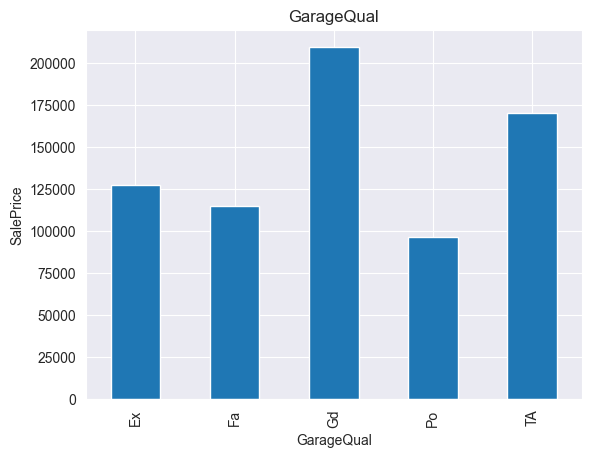

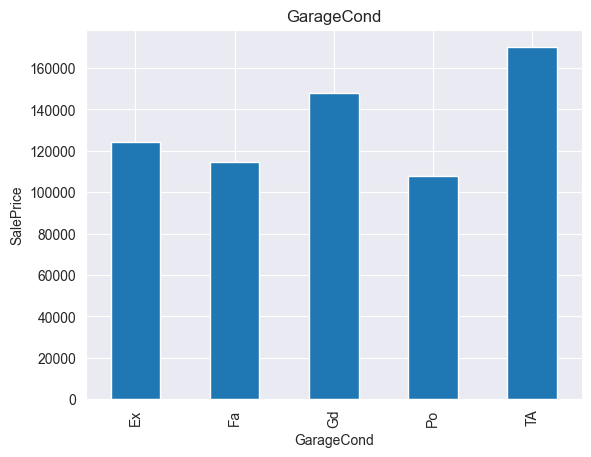

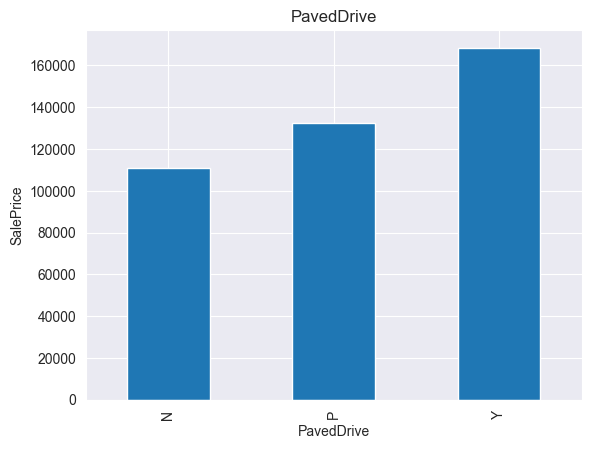

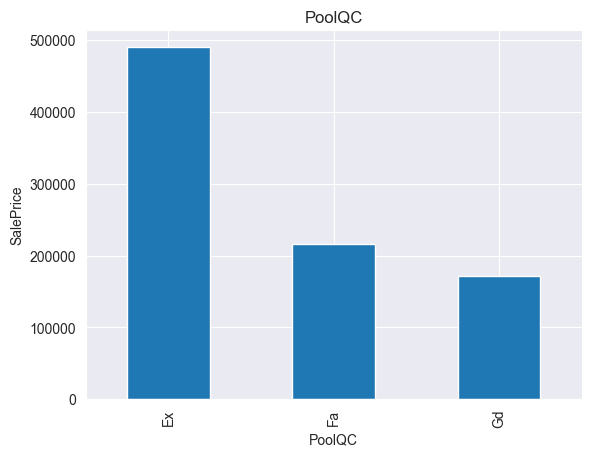

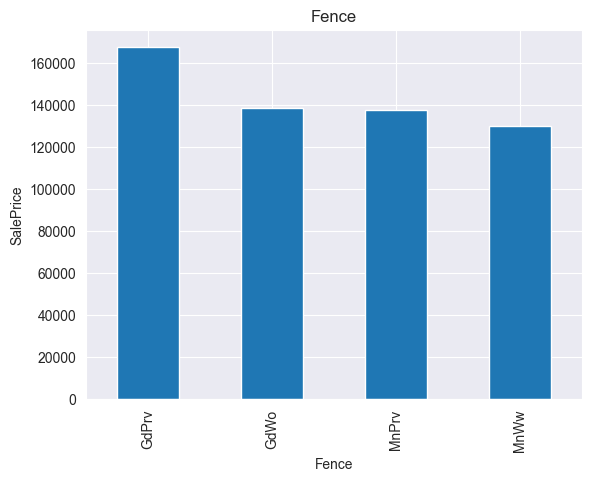

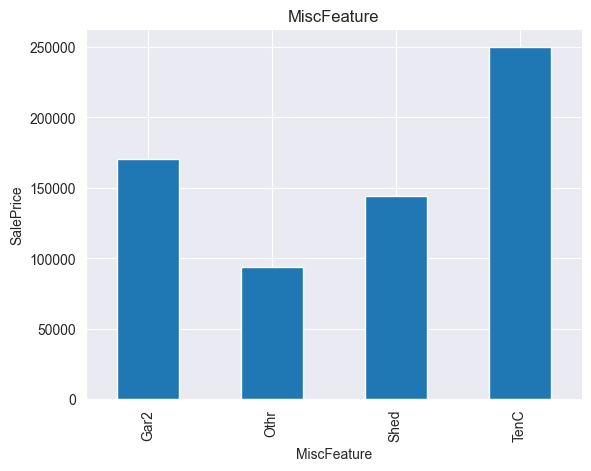

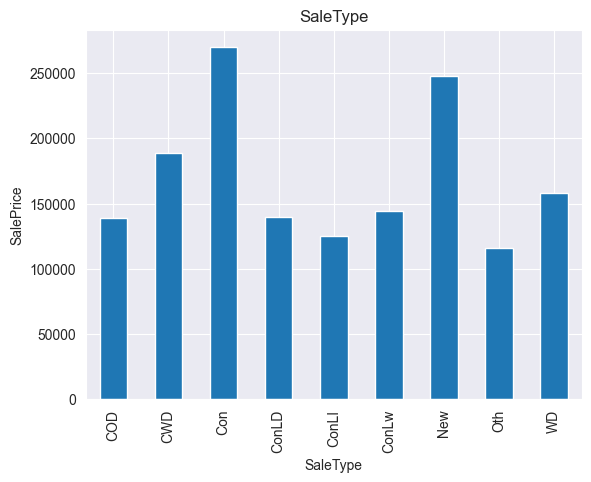

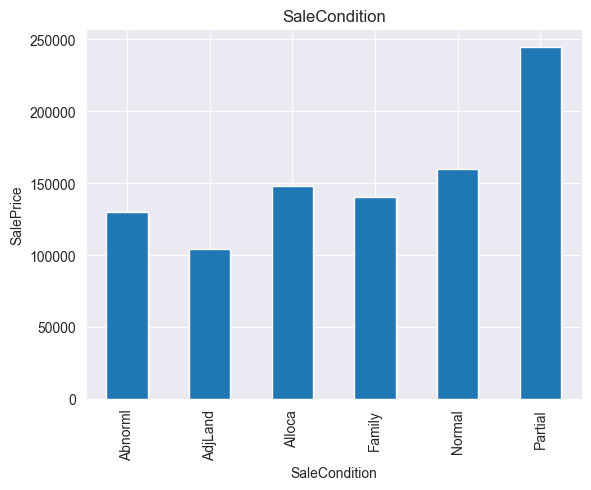

In [198]:
for feature in categorical_feature :
    data = df.copy()
    data.groupby(feature)['SalePrice'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.title(feature)
    plt.show()